# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/k-karimli/FlyRankWeek1/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

### Research Question

Which search performance signals are associated with higher visibility and engagement?

### Decision Supported

This project supports content optimization decisions. By analyzing search performance signals, it helps identify which content may need improvement and which content is performing well.

### Unit of Analysis

One row represents the daily performance of one content item for one client.

### Output

The final output will be a ranking signal analysis with practical recommendations for content improvement.

In [19]:
!pip -q install duckdb huggingface_hub

print("Lane: Ranking Signal Analysis")

research_question = (
    "Which search performance signals are associated "
    "with higher visibility and engagement?"
)

print("Research Question:")
print(research_question)

Lane: Ranking Signal Analysis
Research Question:
Which search performance signals are associated with higher visibility and engagement?


## 2. Data

### Dataset

This project uses the **FlyRank Internship Warehouse** dataset.

### Main Table

- `fact_content_daily_performance`

### Time Window

For the initial analysis, only **March 2026** is used.

### Unit of Analysis

One row represents the daily performance of one content item for one client.

### Features Used

- gsc_impressions
- gsc_clicks
- gsc_avg_position
- ga4_sessions
- ga4_engaged_sessions

### Excluded Columns

The following information is excluded:

- Client identifiers as model features.
- Future information that could cause data leakage.
- Any client-identifying information.

This project uses only public-safe aggregated performance data.

In [20]:
from huggingface_hub import login, snapshot_download
from google.colab import userdata

login(userdata.get("HF_TOKEN"))

dataset_path = snapshot_download(
    repo_id="FlyRank/internship-warehouse",
    repo_type="dataset"
)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 24 files:   0%|          | 0/24 [00:00<?, ?it/s]

## 3. Methodology

### Approach

This project uses an exploratory data analysis approach to study ranking signals.

The goal is to observe whether search performance metrics are associated with higher visibility and engagement.

### Features

The analysis uses:

- gsc_impressions
- gsc_clicks
- gsc_avg_position
- ga4_sessions
- ga4_engaged_sessions

### Baseline

The baseline is a simple ranking based on Google Search impressions.

Pages with more impressions are assumed to have higher visibility.

### Validation

This project compares simple descriptive statistics instead of building a complex prediction model.

### Leakage Check

Client identifiers are not used as predictive features.

Future information is excluded from the analysis.

In [21]:
print("Methodology")

features = [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "ga4_sessions",
    "ga4_engaged_sessions"
]

print("Features:")
for feature in features:
    print("-", feature)

print("\nBaseline:")
print("Pages are ranked by gsc_impressions.")

con.sql("""
SELECT
    AVG(gsc_impressions) AS avg_impressions,
    AVG(gsc_clicks) AS avg_clicks,
    AVG(gsc_avg_position) AS avg_position,
    AVG(ga4_sessions) AS avg_sessions
FROM march
""")

Methodology
Features:
- gsc_impressions
- gsc_clicks
- gsc_avg_position
- ga4_sessions
- ga4_engaged_sessions

Baseline:
Pages are ranked by gsc_impressions.


┌───────────────────┬─────────────────────┬────────────────────┬─────────────────────┐
│  avg_impressions  │     avg_clicks      │    avg_position    │    avg_sessions     │
│      double       │       double        │       double       │       double        │
├───────────────────┼─────────────────────┼────────────────────┼─────────────────────┤
│ 28.51811900731788 │ 0.08350781770601637 │ 15.826651214110573 │ 0.19051401972580398 │
└───────────────────┴─────────────────────┴────────────────────┴─────────────────────┘

## 4. Results (vs baseline)

### Summary

This section presents simple descriptive statistics from the March 2026 dataset.

The baseline ranks pages by Google Search impressions.

The analysis focuses on impressions, clicks, average position and sessions.

These results are descriptive and do not imply causality.

In [22]:
print("=== Results ===")

# Total rows
con.sql("""
SELECT COUNT(*) AS total_rows
FROM march
""").show()

# Average metrics
con.sql("""
SELECT
    AVG(gsc_impressions) AS avg_impressions,
    AVG(gsc_clicks) AS avg_clicks,
    AVG(gsc_avg_position) AS avg_position,
    AVG(ga4_sessions) AS avg_sessions
FROM march
""").show()

print("\nTop 10 pages by impressions")

con.sql("""
SELECT
    content_hash_id,
    gsc_impressions,
    gsc_clicks,
    gsc_avg_position
FROM march
ORDER BY gsc_impressions DESC
LIMIT 10
""").show()

print("\nTop 10 pages by clicks")

con.sql("""
SELECT
    content_hash_id,
    gsc_clicks,
    gsc_impressions
FROM march
ORDER BY gsc_clicks DESC
LIMIT 10
""").show()



=== Results ===
┌────────────┐
│ total_rows │
│   int64    │
├────────────┤
│    9841378 │
└────────────┘

┌───────────────────┬─────────────────────┬────────────────────┬─────────────────────┐
│  avg_impressions  │     avg_clicks      │    avg_position    │    avg_sessions     │
│      double       │       double        │       double       │       double        │
├───────────────────┼─────────────────────┼────────────────────┼─────────────────────┤
│ 28.51811900731788 │ 0.08350781770601637 │ 15.826651214109948 │ 0.19051401972580398 │
└───────────────────┴─────────────────────┴────────────────────┴─────────────────────┘


Top 10 pages by impressions
┌──────────────────────────┬─────────────────┬────────────┬─────────────────────┐
│     content_hash_id      │ gsc_impressions │ gsc_clicks │  gsc_avg_position   │
│         varchar          │      int64      │   int64    │       double        │
├──────────────────────────┼─────────────────┼────────────┼─────────────────────┤
│ content_44f

## 5. Limitations

This analysis has several limitations.

- The dataset is observational and cannot prove causality.
- Only March 2026 data is analyzed.
- Client identifiers are not used as model features.
- Missing GA4 data may affect some engagement metrics.
- Results should be interpreted as decision-support rather than proof.

In [23]:
print("Dataset limitations")

con.sql("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(*) FILTER (
        WHERE ga4_data_available IS TRUE
    ) AS ga4_available,
    COUNT(*) FILTER (
        WHERE ga4_data_available IS FALSE
    ) AS ga4_missing
FROM march
""").show()

Dataset limitations
┌────────────┬───────────────┬─────────────┐
│ total_rows │ ga4_available │ ga4_missing │
│   int64    │     int64     │    int64    │
├────────────┼───────────────┼─────────────┤
│    9841378 │        413966 │     6408671 │
└────────────┴───────────────┴─────────────┘



## 6. Ranked Recommendations

Based on this analysis, the following actions are recommended.

1. Monitor pages with high impressions but low clicks.
2. Review pages with poor average search position.
3. Improve engagement for pages with many impressions but few sessions.
4. Continue monitoring pages with strong search performance.

These recommendations are based on observed search performance metrics.

In [24]:
print("Top opportunities")

con.sql("""
SELECT
    content_hash_id,
    gsc_impressions,
    gsc_clicks,
    gsc_avg_position
FROM march
WHERE gsc_impressions > 100
ORDER BY gsc_clicks ASC
LIMIT 10
""").show()

Top opportunities
┌──────────────────────────┬─────────────────┬────────────┬────────────────────┐
│     content_hash_id      │ gsc_impressions │ gsc_clicks │  gsc_avg_position  │
│         varchar          │      int64      │   int64    │       double       │
├──────────────────────────┼─────────────────┼────────────┼────────────────────┤
│ content_a7da352b73b02668 │             191 │          0 │  7.832460732984293 │
│ content_712c365258cee05c │             223 │          0 │   3.89237668161435 │
│ content_8935ed68eca88b01 │             113 │          0 │  5.654867256637168 │
│ content_347a278bb1a646f5 │             134 │          0 │  2.082089552238806 │
│ content_4cd532e5e9edc02b │             205 │          0 │ 3.6341463414634148 │
│ content_0c29bba4e77ab325 │             153 │          0 │  5.594771241830065 │
│ content_6cf70a5cb30e76f2 │             214 │          0 │  6.509345794392523 │
│ content_e833e04503f07324 │             215 │          0 │  6.986046511627907 │
│ content_

## 7. Artifacts the paper embeds

This section contains simple charts and summary tables generated from the analysis.

The following artifacts are included:

- Distribution of GSC impressions
- Top 10 pages by clicks
- Summary statistics
- Opportunity ranking table

These figures help visualize the observed search performance patterns.

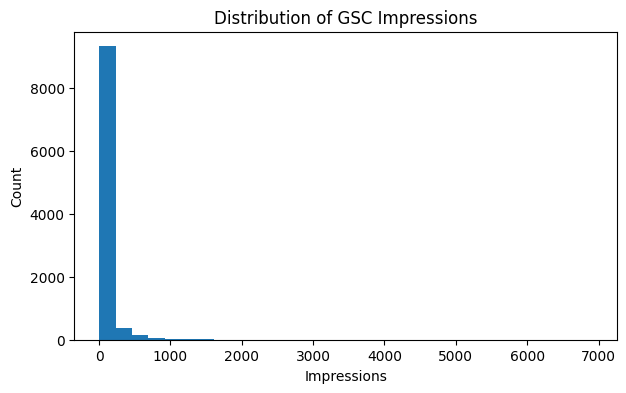

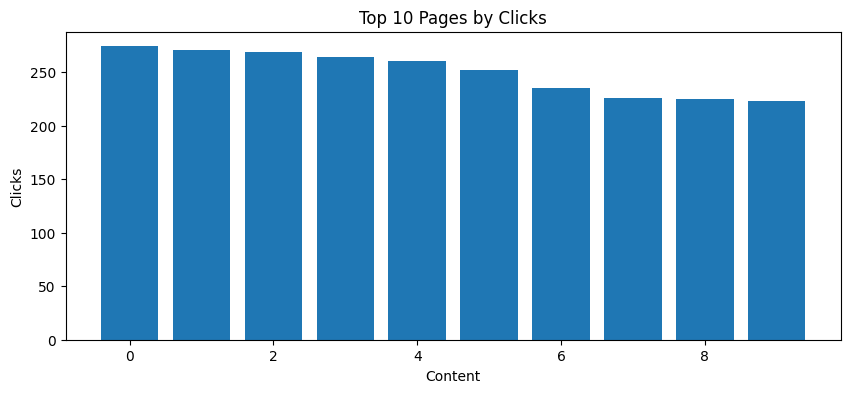

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

df = con.sql("""
SELECT
    gsc_impressions,
    gsc_clicks
FROM march
LIMIT 10000
""").df()

plt.figure(figsize=(7,4))

plt.hist(df["gsc_impressions"], bins=30)

plt.title("Distribution of GSC Impressions")
plt.xlabel("Impressions")
plt.ylabel("Count")

plt.show()

top = con.sql("""
SELECT
    content_hash_id,
    gsc_clicks
FROM march
ORDER BY gsc_clicks DESC
LIMIT 10
""").df()

plt.figure(figsize=(10,4))

plt.bar(range(len(top)), top["gsc_clicks"])

plt.title("Top 10 Pages by Clicks")
plt.xlabel("Content")
plt.ylabel("Clicks")

plt.show()



## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
